# Classification Model Comparison

In this notebook, we will train and compare multiple supervised machine
learning classification algorithms on the same dataset.

The models we will compare are:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Support Vector Machine (SVM)
6. Naive Bayes
7. Gradient Boosting
8. Extra Trees
9. XGBoost
10. LightGBM
11. CatBoost

We will use the same:

- Dataset
- Training data
- Testing data
- Evaluation metrics

This allows us to make a fair comparison between the models.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
print("Shape:", X.shape)

Shape: (150, 4)


In [4]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [5]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [8]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [9]:
results = []

scaled_models = {
    "Logistic Regression",
    "KNN",
    "SVM"
}

for name, model in models.items():

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })

In [10]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,KNN,0.933333,0.944444,0.933333,0.932660
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
3,Random Forest,0.900000,0.902357,0.900000,0.899749
4,SVM,0.966667,0.969697,0.966667,0.966583
5,Naive Bayes,0.966667,0.969697,0.966667,0.966583
6,Gradient Boosting,0.966667,0.969697,0.966667,0.966583
7,Extra Trees,0.933333,0.933333,0.933333,0.933333


In [11]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.966667,0.969697,0.966667,0.966583
1,Gradient Boosting,0.966667,0.969697,0.966667,0.966583
2,SVM,0.966667,0.969697,0.966667,0.966583
3,Logistic Regression,0.933333,0.933333,0.933333,0.933333
4,KNN,0.933333,0.944444,0.933333,0.932660
5,Decision Tree,0.933333,0.933333,0.933333,0.933333
6,Extra Trees,0.933333,0.933333,0.933333,0.933333
7,Random Forest,0.900000,0.902357,0.900000,0.899749


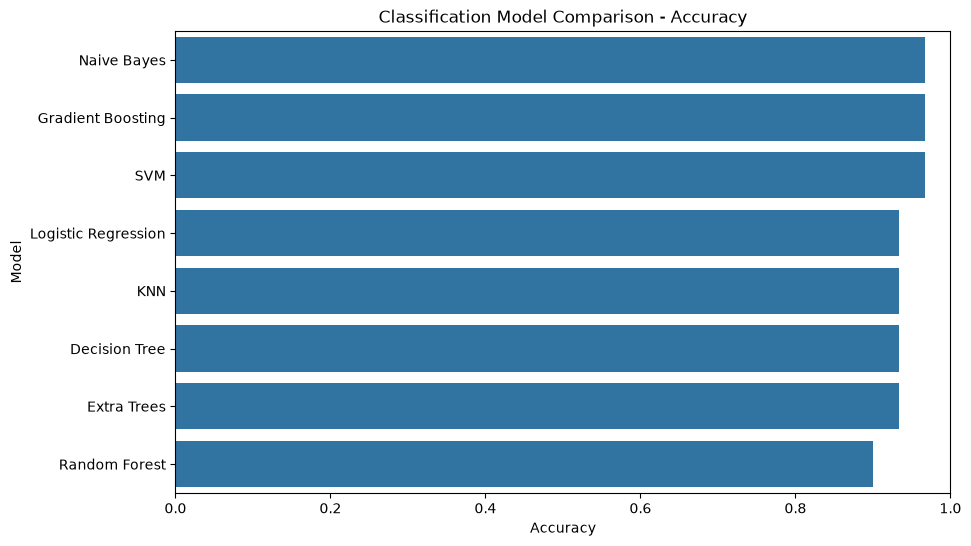

In [12]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Classification Model Comparison - Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

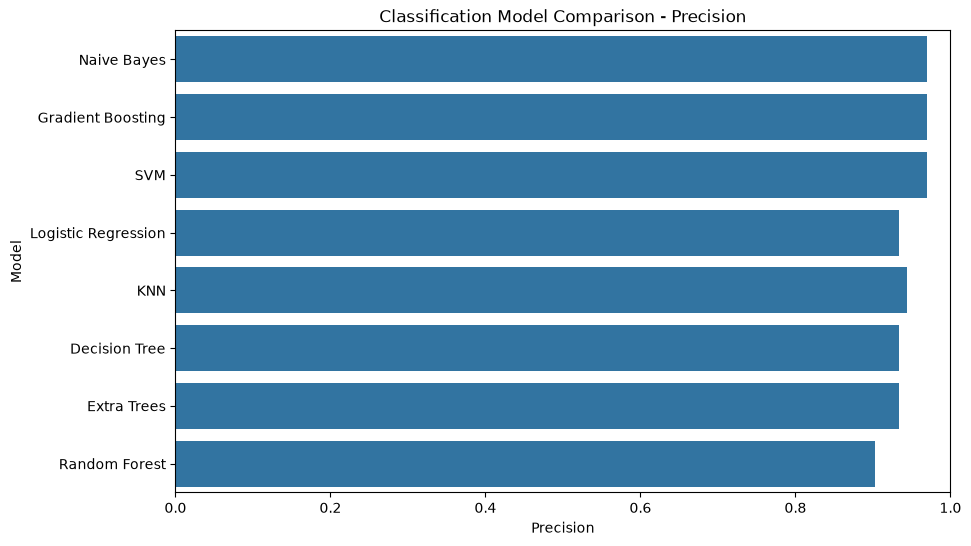

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Precision",
    y="Model"
)

plt.title("Classification Model Comparison - Precision")
plt.xlabel("Precision")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

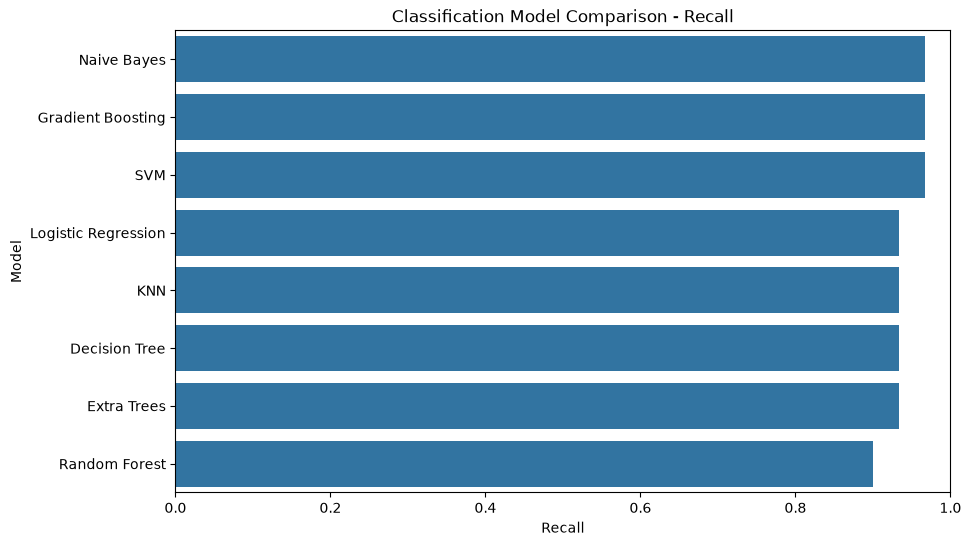

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Recall",
    y="Model"
)

plt.title("Classification Model Comparison - Recall")
plt.xlabel("Recall")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

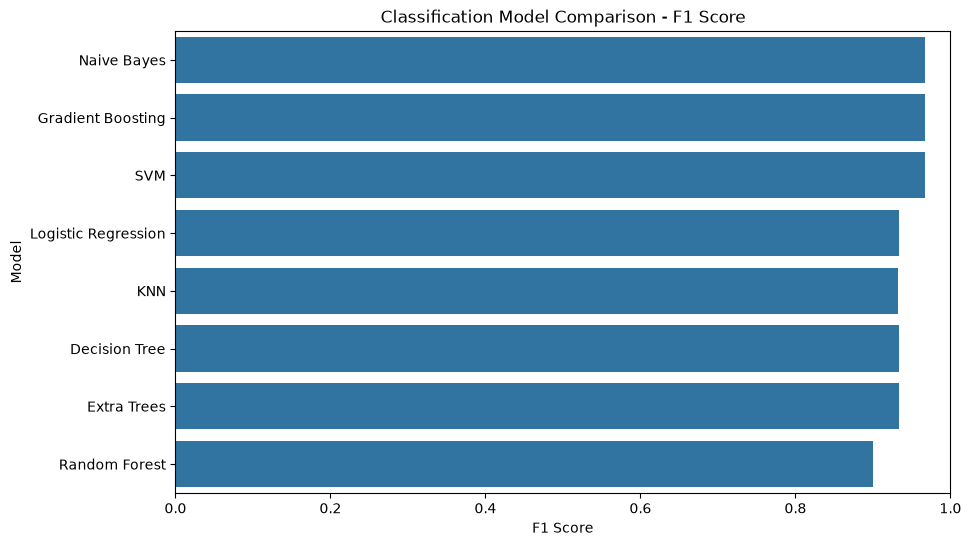

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title("Classification Model Comparison - F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

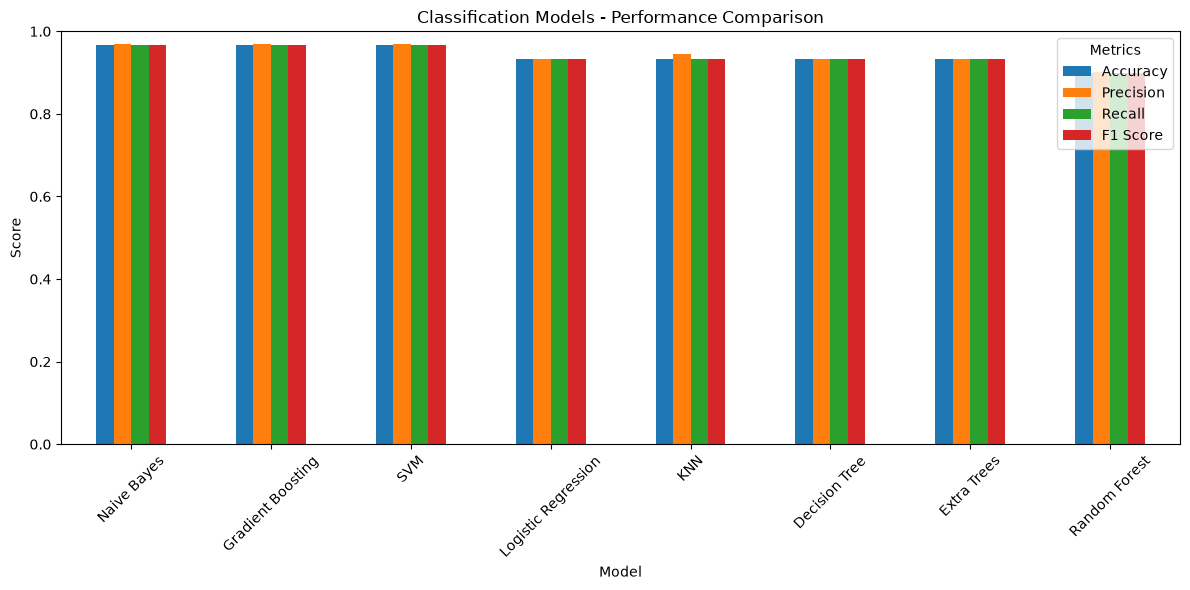

In [16]:
comparison = results_df.set_index("Model")

comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Models - Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.legend(
    title="Metrics"
)

plt.tight_layout()

plt.show()

In [17]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Naive Bayes


In [18]:
best_model = models[best_model_name]

if best_model_name in scaled_models:
    best_pred = best_model.predict(X_test_scaled)
else:
    best_pred = best_model.predict(X_test)